In [1]:
library(tidyverse)
library(pheatmap)

── Attaching core tidyverse packages ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
gns <- read_csv("BP_RNAforHeatmap.csv")
cnt <- read_csv("mock_V_rescue.csv_norm_counts.csv")

Rows: 924 Columns: 1
── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (1): V1

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 48440 Columns: 7
── Column specification ──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr (1): V1
dbl (6): MESC_MOCK_1, MESC_MOCK_2, MESC_MOCK_3, MESC_RES_1, MESC_RES_2, MESC...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [3]:
glimpse(gns)
glimpse(cnt)

Rows: 924
Columns: 1
$ V1 <chr> "ENSMUSG00000025902.13", "ENSMUSG00000099032.2", "ENSMUSG0000002592…
Rows: 48,440
Columns: 7
$ MESC_MOCK_1 <dbl> 0.000000, 0.000000, 3.633713, 0.000000, 0.000000, 0.000000…
$ MESC_MOCK_2 <dbl> 0.0000000, 0.0000000, 0.0000000, 0.0000000, 0.0000000, 0.0…
$ MESC_MOCK_3 <dbl> 0.00000, 0.00000, 0.00000, 0.00000, 0.00000, 0.00000, 0.00…
$ MESC_RES_1  <dbl> 0.0000000, 0.0000000, 13.9223919, 0.0000000, 0.0000000, 0.…
$ MESC_RES_2  <dbl> 0.000000, 0.000000, 18.106922, 0.000000, 0.000000, 0.00000…
$ MESC_RES_3  <dbl> 0.000000, 0.000000, 16.517148, 0.000000, 0.000000, 0.00000…
$ V1          <chr> "ENSMUSG00000102693.1", "ENSMUSG00000064842.1", "ENSMUSG00…


In [5]:
cnt2 <- cnt |> mutate(sumcounts = MESC_MOCK_1+ MESC_MOCK_2 + MESC_MOCK_3+ MESC_RES_1 + MESC_RES_2 + MESC_RES_3 ) |> 
    filter(sumcounts != 0) |>
    select(!sumcounts)
glimpse(cnt2)

Rows: 31,676
Columns: 7
$ MESC_MOCK_1 <dbl> 3.633713e+00, 0.000000e+00, 7.049403e+01, 0.000000e+00, 2.…
$ MESC_MOCK_2 <dbl> 0.000000e+00, 0.000000e+00, 1.011781e+02, 0.000000e+00, 0.…
$ MESC_MOCK_3 <dbl> 0.000000, 0.000000, 101.523209, 0.000000, 0.000000, 1944.6…
$ MESC_RES_1  <dbl> 1.392239e+01, 9.281595e-01, 1.577871e+02, 9.281595e-01, 2.…
$ MESC_RES_2  <dbl> 18.106922, 0.000000, 134.978876, 0.000000, 1.646084, 1578.…
$ MESC_RES_3  <dbl> 16.517148, 0.000000, 162.418618, 1.835239, 0.000000, 1842.…
$ V1          <chr> "ENSMUSG00000051951.5", "ENSMUSG00000104017.1", "ENSMUSG00…


In [6]:
hm <- cnt2 |> filter(V1 %in% gns$V1)
hmnams <- as.vector(hm$V1)
hm$V1 <- NULL
hm <- as.matrix(hm)
rownames(hm) <- hmnams

pdf 
  2

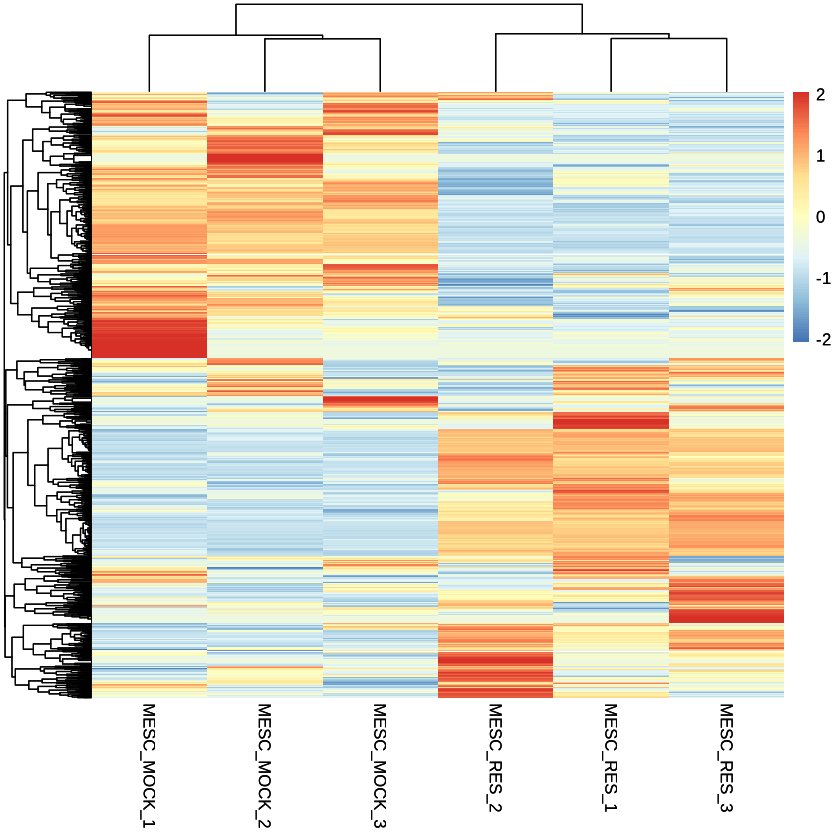

In [9]:
plt <- pheatmap(hm,
         scale= "row", show_rownames = F, cluster_cols= T,cluster_rows = T, border_color =NA , threeheight_row = 0
        )

plt

pdf("heatmap4.pdf", width = 8, height = 12)
plt
dev.off()

In [8]:
glimpse(hm)


 num [1:842, 1:6] 11.63 139.53 1.45 6.54 75.58 ...
 - attr(*, "dimnames")=List of 2
  ..$ : chr [1:842] "ENSMUSG00000025902.13" "ENSMUSG00000099032.2" "ENSMUSG00000025927.13" "ENSMUSG00000026062.12" ...
  ..$ : chr [1:6] "MESC_MOCK_1" "MESC_MOCK_2" "MESC_MOCK_3" "MESC_RES_1" ...


In [ ]:
#write(gns$geneId[!(gns$geneId %in% as.vector(cnt2$V1))], "nograficables.txt")